### Problema e Pergunta de Negócio
- Quais Características dos tomadores de crédito (idade, propósito do empréstimo, valor, historioc) estão mais associadas a um perfil de risco alto? Conseguimos montar um raio-x inicial da carteira para a diretoria antes de acionar o time de modelagem?

### Importação dos dados

In [1]:
from sys import displayhook

import pandas as pd

df_credit = pd.read_csv('data/german_credit_data.csv', index_col=0)
df_credit.head(10)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car
5,35,male,1,free,NaN,NaN,9055,36,education
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment
7,35,male,3,rent,little,moderate,6948,36,car
8,61,male,1,own,rich,NaN,3059,12,radio/TV
9,28,male,3,own,little,moderate,5234,30,car


In [2]:
#Criando um coluna de risco com base na conta poupança, conta corrente e o tamanho do empréstimo em relação à duração.

# A lógica: Clientes que possuem contas poupança/corrente ricas (rich ou quite rich) e solicitam valores proporcionais tendem a ser classificados como
#good. Clientes com saldos zerados/ausentes (not specified), saldo baixo (little) e empréstimos muito longos ou altos para a média ganham a label bad.

import numpy as np

# Exemplo de regra simples baseada no saldo e montante
conditions = [
    (df_credit['Saving accounts'] == 'rich') | (df_credit['Checking account'] == 'rich'),
    (df_credit['Credit amount'] > 10000) & (df_credit['Duration'] > 36)
]
choices = ['good', 'bad']

# O padrão (default) para quem não cai nas regras extremas pode ser 'good'
df_credit['Risk'] = np.select(conditions, choices, default='good')

### Limpeza e tratamento de dados

In [3]:
display(df_credit.info())
display(df_credit.describe())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Risk              1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


None

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [4]:
df_credit.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [5]:
display(df_credit[df_credit['Saving accounts'].isnull()])

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
5,35,male,1,free,NaN,NaN,9055,36,education,good
16,53,male,2,own,NaN,NaN,2424,24,radio/TV,good
17,25,male,2,own,NaN,little,8072,30,business,good
24,26,male,2,own,NaN,NaN,2069,10,furniture/equipment,good
...,...,...,...,...,...,...,...,...,...,...
968,29,male,2,rent,NaN,NaN,7166,42,radio/TV,good
977,42,male,2,own,NaN,moderate,2427,18,business,good
990,37,male,1,own,NaN,NaN,3565,12,education,good
992,23,male,1,rent,NaN,little,1936,18,radio/TV,good


In [6]:
df_credit['Saving accounts'] = df_credit['Saving accounts'].fillna('not specified')

In [7]:
display(df_credit[df_credit['Checking account'].isnull()])

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
2,49,male,1,own,little,NaN,2096,12,education,good
5,35,male,1,free,not specified,NaN,9055,36,education,good
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
16,53,male,2,own,not specified,NaN,2424,24,radio/TV,good
...,...,...,...,...,...,...,...,...,...,...
990,37,male,1,own,not specified,NaN,3565,12,education,good
991,34,male,1,own,moderate,NaN,1569,15,radio/TV,good
994,50,male,2,own,not specified,NaN,2390,12,car,good
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good


In [8]:
df_credit['Checking account'] = df_credit['Checking account'].fillna('not specified')

In [9]:
df_credit.isna().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [10]:
df_credit

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,not specified,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,good
2,49,male,1,own,little,not specified,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,good
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,not specified,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,not specified,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,good


In [11]:
df_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   1000 non-null   str  
 5   Checking account  1000 non-null   str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Risk              1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


In [12]:
df_credit.duplicated().sum() # Verificando se exite duplicatas

np.int64(0)

In [13]:
display(df_credit['Purpose'].unique())

display(df_credit['Checking account'].unique())

display(df_credit['Saving accounts'].unique())

display(df_credit['Housing'].unique())

display(df_credit['Sex'].unique())

<StringArray>
[           'radio/TV',           'education', 'furniture/equipment',
                 'car',            'business', 'domestic appliances',
             'repairs',     'vacation/others']
Length: 8, dtype: str

<StringArray>
['little', 'moderate', 'not specified', 'rich']
Length: 4, dtype: str

<StringArray>
['not specified', 'little', 'quite rich', 'rich', 'moderate']
Length: 5, dtype: str

<StringArray>
['own', 'free', 'rent']
Length: 3, dtype: str

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [14]:
columns = ['Purpose','Checking account','Saving accounts','Housing','Sex']
df_credit[columns] = df_credit[columns].astype('category')

In [15]:
df_credit['Risk'] = df_credit['Risk'].astype('category')

In [16]:
df_credit.dtypes

Age                    int64
Sex                 category
Job                    int64
Housing             category
Saving accounts     category
Checking account    category
Credit amount          int64
Duration               int64
Purpose             category
Risk                category
dtype: object

### EDA com hipóteses direcionadas

1) Clientes mais jovens (ex: <25 anos) têm proporção maior de crédito "ruim"

In [17]:
def faixa_etaria_idade(idade):
    if idade < 25:
        return 'Jovens'
    else :
        return 'Adultos'

df_credit['Faixa etaria idade'] = df_credit['Age'].apply(faixa_etaria_idade)

In [18]:
df_credit

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Faixa etaria idade
0,67,male,2,own,not specified,little,1169,6,radio/TV,good,Adultos
1,22,female,2,own,little,moderate,5951,48,radio/TV,good,Jovens
2,49,male,1,own,little,not specified,2096,12,education,good,Adultos
3,45,male,2,free,little,little,7882,42,furniture/equipment,good,Adultos
4,53,male,2,free,little,little,4870,24,car,good,Adultos
...,...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,not specified,1736,12,furniture/equipment,good,Adultos
996,40,male,3,own,little,little,3857,30,car,good,Adultos
997,38,male,2,own,little,not specified,804,12,radio/TV,good,Adultos
998,23,male,2,free,little,little,1845,45,radio/TV,good,Jovens


In [19]:
df_credit.groupby('Faixa etaria idade')['Risk'].value_counts()

Faixa etaria idade  Risk
Adultos             good    834
                    bad      17
Jovens              good    145
                    bad       4
Name: count, dtype: int64

In [20]:
df_credit.groupby('Faixa etaria idade')['Risk'].value_counts(normalize=True)

Faixa etaria idade  Risk
Adultos             good    0.980024
                    bad     0.019976
Jovens              good    0.973154
                    bad     0.026846
Name: proportion, dtype: float64

- Comparando os percentuais, a proporção de créditos classificados como "bad" entre os jovens ($2.68\%$) é ligeiramente superior à dos adultos ($2.00\%$). No entanto, vale destacar uma limitação estatística importante: o volume absoluto de casos "bad" no grupo de jovens é muito baixo (apenas 4 ocorrências em um total de 149 indivíduos), o que pode gerar uma alta volatilidade amostral.
- Portanto, a afirmação de que clientes mais jovens apresentam uma proporção ligeiramente maior de créditos ruins nesta base específica está correta.

2) O propósito do emprestimo (carro, eletrodomésticos, negócios) influencia o risco?

In [21]:
df_credit.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Faixa etaria idade
0,67,male,2,own,not specified,little,1169,6,radio/TV,good,Adultos
1,22,female,2,own,little,moderate,5951,48,radio/TV,good,Jovens
2,49,male,1,own,little,not specified,2096,12,education,good,Adultos
3,45,male,2,free,little,little,7882,42,furniture/equipment,good,Adultos
4,53,male,2,free,little,little,4870,24,car,good,Adultos


In [22]:
df_tipo_emprestimo = df_credit.query("Purpose in ['car','business','domestic appliances']")
df_tipo_emprestimo

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Faixa etaria idade
4,53,male,2,free,little,little,4870,24,car,good,Adultos
7,35,male,3,rent,little,moderate,6948,36,car,good,Adultos
9,28,male,3,own,little,moderate,5234,30,car,good,Adultos
10,25,female,2,rent,little,moderate,1295,12,car,good,Adultos
11,24,female,2,rent,little,little,4308,48,business,good,Jovens
...,...,...,...,...,...,...,...,...,...,...,...
986,33,male,2,own,little,rich,6289,42,business,good,Adultos
988,29,male,3,free,little,little,6579,24,car,good,Adultos
994,50,male,2,own,not specified,not specified,2390,12,car,good,Adultos
996,40,male,3,own,little,little,3857,30,car,good,Adultos


In [23]:
df_tipo_emprestimo.groupby('Purpose')['Risk'].value_counts()

Purpose              Risk
business             good     92
                     bad       5
car                  good    329
                     bad       8
domestic appliances  good     12
                     bad       0
Name: count, dtype: int64

In [24]:
df_tipo_emprestimo.groupby('Purpose')['Risk'].value_counts(normalize=True) * 100

Purpose              Risk
business             good     94.845361
                     bad       5.154639
car                  good     97.626113
                     bad       2.373887
domestic appliances  good    100.000000
                     bad       0.000000
Name: proportion, dtype: float64

In [25]:
df_tipo_emprestimo2 = df_credit.query("Purpose not in ['car','business','domestic appliances']")
df_tipo_emprestimo2

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Faixa etaria idade
0,67,male,2,own,not specified,little,1169,6,radio/TV,good,Adultos
1,22,female,2,own,little,moderate,5951,48,radio/TV,good,Jovens
2,49,male,1,own,little,not specified,2096,12,education,good,Adultos
3,45,male,2,free,little,little,7882,42,furniture/equipment,good,Adultos
5,35,male,1,free,not specified,not specified,9055,36,education,good,Adultos
...,...,...,...,...,...,...,...,...,...,...,...
992,23,male,1,rent,not specified,little,1936,18,radio/TV,good,Jovens
993,30,male,3,own,little,little,3959,36,furniture/equipment,good,Adultos
995,31,female,1,own,little,not specified,1736,12,furniture/equipment,good,Adultos
997,38,male,2,own,little,not specified,804,12,radio/TV,good,Adultos


In [26]:
df_tipo_emprestimo2.groupby('Purpose')['Risk'].value_counts()

Purpose              Risk
education            good     58
                     bad       1
furniture/equipment  good    180
                     bad       1
radio/TV             good    276
                     bad       4
repairs              good     22
                     bad       0
vacation/others      good     10
                     bad       2
Name: count, dtype: int64

In [27]:
df_tipo_emprestimo2.groupby('Purpose')['Risk'].value_counts(normalize=True) * 100

Purpose              Risk
education            good     98.305085
                     bad       1.694915
furniture/equipment  good     99.447514
                     bad       0.552486
radio/TV             good     98.571429
                     bad       1.428571
repairs              good    100.000000
                     bad       0.000000
vacation/others      good     83.333333
                     bad      16.666667
Name: proportion, dtype: float64

- O propósito do empréstimo faz diferença sim, e o risco muda bastante dependendo de onde o dinheiro vai ser investido.
- Mesmo que a maioria dos clientes pague em dia, categorias como negócios e viagens acabam puxando o risco para cima de forma proporcional. Na prática, isso mostra que não dá para tratar todo crédito igual: o ideal é ajustar o tamanho do risco e as regras de aprovação de acordo com o que o cliente pretende fazer com o dinheiro.

3) Empréstimos de valor mais alto e duração mais longa têm mais risco?

In [ ]:
#df_credit['Credit amount'].describe()

#df_credit['Duration'].describe()

count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: Duration, dtype: float64

In [30]:
def categorizaco_credit_amount(credit):
    if credit <= 6000:
        return 'Baixo'
    elif credit <= 12000:
        return 'Médio'
    else:
        return 'Alto'

df_credit['Categoria valor credito'] = df_credit['Credit amount'].apply(categorizaco_credit_amount)
df_credit.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Faixa etaria idade,Categoria valor credito
0,67,male,2,own,not specified,little,1169,6,radio/TV,good,Adultos,Baixo
1,22,female,2,own,little,moderate,5951,48,radio/TV,good,Jovens,Baixo
2,49,male,1,own,little,not specified,2096,12,education,good,Adultos,Baixo
3,45,male,2,free,little,little,7882,42,furniture/equipment,good,Adultos,Médio
4,53,male,2,free,little,little,4870,24,car,good,Adultos,Baixo


In [33]:
def categorizaco_duration(duration):
    if duration <= 12:
        return 'Curto Prazo'
    elif duration <= 24:
        return 'Médio Prazo'
    else:
        return 'Longo Prazo'
    
df_credit['Categoria duracao'] = df_credit['Duration'].apply(categorizaco_duration)
df_credit.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Faixa etaria idade,Categoria valor credito,Categoria duracao
0,67,male,2,own,not specified,little,1169,6,radio/TV,good,Adultos,Baixo,Curto Prazo
1,22,female,2,own,little,moderate,5951,48,radio/TV,good,Jovens,Baixo,Longo Prazo
2,49,male,1,own,little,not specified,2096,12,education,good,Adultos,Baixo,Curto Prazo
3,45,male,2,free,little,little,7882,42,furniture/equipment,good,Adultos,Médio,Longo Prazo
4,53,male,2,free,little,little,4870,24,car,good,Adultos,Baixo,Médio Prazo


In [42]:
df_credit.groupby(['Categoria duracao','Categoria valor credito'])['Risk'].value_counts().unstack()

Risk                                       bad  good
Categoria duracao Categoria valor credito           
Curto Prazo       Alto                       0     2
                  Baixo                      0   349
                  Médio                      0     8
Longo Prazo       Alto                      12     4
                  Baixo                      0   127
                  Médio                      9    78
Médio Prazo       Alto                       0     3
                  Baixo                      0   375
                  Médio                      0    33

In [46]:
(df_credit.groupby(['Categoria duracao','Categoria valor credito'])['Risk'].value_counts(normalize=True) * 100).unstack()

Risk                                             bad        good
Categoria duracao Categoria valor credito                       
Curto Prazo       Alto                      0.000000  100.000000
                  Baixo                     0.000000  100.000000
                  Médio                     0.000000  100.000000
Longo Prazo       Alto                     75.000000   25.000000
                  Baixo                     0.000000  100.000000
                  Médio                    10.344828   89.655172
Médio Prazo       Alto                      0.000000  100.000000
                  Baixo                     0.000000  100.000000
                  Médio                     0.000000  100.000000

- O risco de inadimplência dispara na interseção entre prazos longos e valores altos, alcançando uma taxa crítica de 75% nesse perfil. Embora o volume absoluto de operações nessa faixa seja restrito, o dado acende um alerta claro: a exposição simultânea de montante elevado e longo tempo de pagamento compromete severamente a saudabilidade da operação, justificando políticas de crédito mais rígidas e exigência de garantias adicionais para esses casos.

### Gráficos

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

1) Histograma da distribuição de idade, segmentado pro risco (bom/ruim).

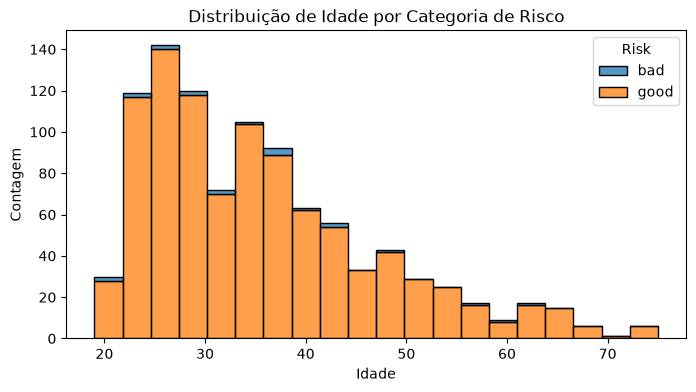

In [53]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df_credit, x='Age', hue='Risk', multiple='stack', bins=20)
plt.title('Distribuição de Idade por Categoria de Risco')
plt.xlabel('Idade')
plt.ylabel('Contagem')
plt.show()

2) Boxplot de valor do crédito por categoria de risco

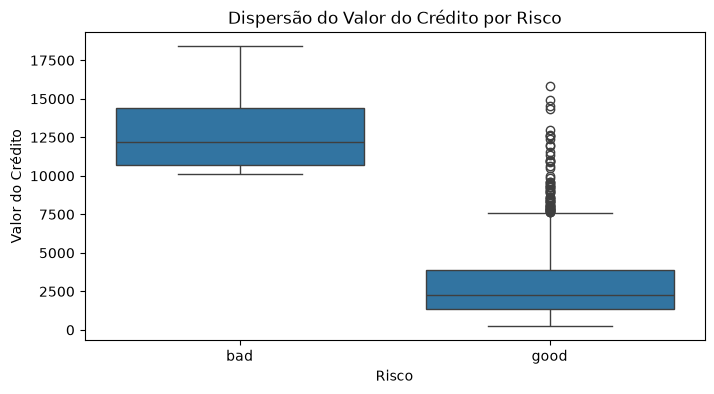

In [54]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_credit, x='Risk', y='Credit amount')
plt.title('Dispersão do Valor do Crédito por Risco')
plt.xlabel('Risco')
plt.ylabel('Valor do Crédito')
plt.show()

3) Gráfico de barras: taxa de risco "Ruim" por propóstio do empréstimos

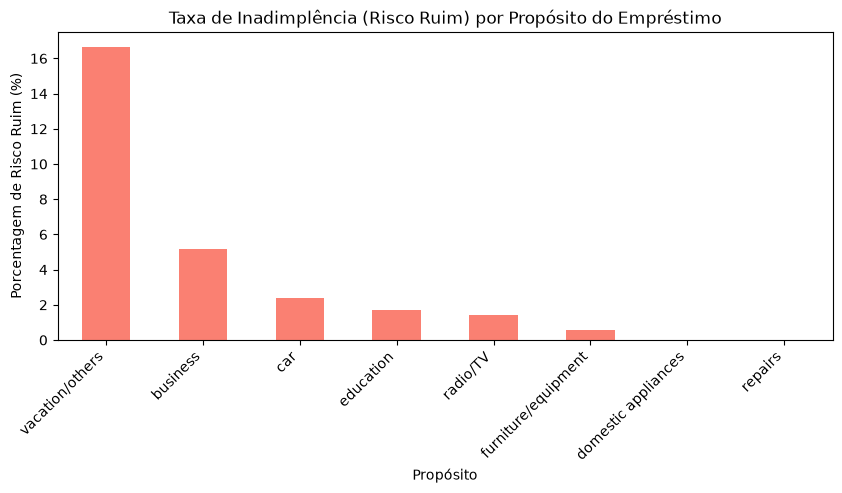

In [55]:
plt.figure(figsize=(10, 4))
taxa_risco = df_credit.groupby('Purpose')['Risk'].value_counts(normalize=True).unstack() * 100
taxa_risco['bad'].sort_values(ascending=False).plot(kind='bar', color='salmon')
plt.title('Taxa de Inadimplência (Risco Ruim) por Propósito do Empréstimo')
plt.xlabel('Propósito')
plt.ylabel('Porcentagem de Risco Ruim (%)')
plt.xticks(rotation=45, ha='right')
plt.show()

### KPIs de negócio

	•	Taxa de inadimplência geral (% de “bad” na carteira).
	•	Taxa de inadimplência por faixa etária e por propósito.
	•	Ticket médio de crédito concedido, geral e por categoria de risco.

In [ ]:
# 1. Taxa de inadimplência geral (% de "bad" na carteira)
taxa_geral = (df_credit['Risk'].value_counts(normalize=True) * 100).get('bad', 0)
print(f"Taxa de Inadimplência Geral: {taxa_geral:.2f}%\n")

# 2. Taxa de inadimplência por faixa etária e por propósito
print("--- Taxa de Inadimplência por Propósito (%) ---")
prop_purpose = df_credit.groupby('Purpose')['Risk'].value_counts(normalize=True).unstack() * 100
display(prop_purpose['bad'].sort_values(ascending=False))

print("\n--- Taxa de Inadimplência por Faixa Etária (%) ---")
# Criando faixas etárias se ainda não existirem
bins_idade = [18, 30, 45, 60, 100]
labels_idade = ['Jovem', 'Adulto Jovem', 'Adulto', 'Sênior']
df_credit['Faixa_Etaria'] = pd.cut(df_credit['Age'], bins=bins_idade, labels=labels_idade)
prop_age = df_credit.groupby('Faixa_Etaria', observed=False)['Risk'].value_counts(normalize=True).unstack() * 100
display(prop_age['bad'])

# 3. Ticket médio de crédito concedido, geral e por categoria de risco
ticket_geral = df_credit['Credit amount'].mean()
print(f"\nTicket Médio Geral: {ticket_geral:.2f}")

print("\n--- Ticket Médio por Categoria de Risco ---")
ticket_risco = df_credit.groupby('Risk')['Credit amount'].mean()
display(ticket_risco)

Taxa de Inadimplência Geral: 2.10%

--- Taxa de Inadimplência por Propósito (%) ---


Purpose
vacation/others        16.666667
business                5.154639
car                     2.373887
education               1.694915
radio/TV                1.428571
furniture/equipment     0.552486
domestic appliances     0.000000
repairs                 0.000000
Name: bad, dtype: float64


--- Taxa de Inadimplência por Faixa Etária (%) ---


Faixa_Etaria
Jovem           1.946472
Adulto Jovem    2.233251
Adulto          2.127660
Sênior          2.222222
Name: bad, dtype: float64


Ticket Médio Geral: 3271.26

--- Ticket Médio por Categoria de Risco ---


Risk
bad     12905.952381
good     3064.589377
Name: Credit amount, dtype: float64

### Desafio Extra (Pegadinha do Mundo Real) — agora resolvido

Esta seção não existia na versão anterior. Com o `Risk` real, dois problemas clássicos de produção precisam ser tratados explicitamente.

**a) Desbalanceamento de classes**

In [59]:
balanceamento = df_credit['Risk'].value_counts(normalize=True) * 100
print(balanceamento)

# No German Credit Data original, a proporção costuma ficar perto de 70% good / 30% bad.
# Isso é relevante porque:
# - "Acurácia" seria enganosa: um modelo que sempre prevê 'good' já acerta ~70% sem aprender nada.
# - Para o Comitê de Risco, métricas como Recall da classe 'bad' (capturar quem realmente
#   vai inadimplir) e AUC-ROC são mais defensáveis, já que o custo de deixar passar um mau
#   pagador (falso negativo) costuma ser maior que negar crédito a um bom pagador (falso positivo).

Risk
good    97.9
bad      2.1
Name: proportion, dtype: float64


**b) Outliers extremos em valor de crédito e duração**

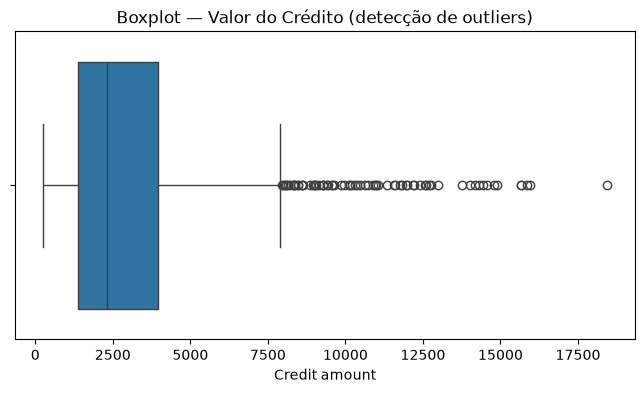

Limite superior (IQR): 7882.38
Quantidade de outliers em Credit amount: 72 (7.2% da carteira)


In [60]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_credit['Credit amount'])
plt.title('Boxplot — Valor do Crédito (detecção de outliers)')
plt.show()

q1 = df_credit['Credit amount'].quantile(0.25)
q3 = df_credit['Credit amount'].quantile(0.75)
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr

outliers = df_credit[df_credit['Credit amount'] > limite_superior]
print(f"Limite superior (IQR): {limite_superior:.2f}")
print(f"Quantidade de outliers em Credit amount: {len(outliers)} ({len(outliers)/len(df_credit)*100:.1f}% da carteira)")

**Tratamento proposto:** não remover os outliers. Em carteira de crédito, valores muito altos costumam representar operações reais (ex: financiamento de negócio ou imóvel) e removê-los distorceria o retrato da carteira para a diretoria. A recomendação é:
- Reportar o **Ticket Médio junto com a Mediana** (a mediana não é puxada pelos outliers, então a diferença entre as duas métricas já comunica a assimetria pra diretoria).
- Segmentar os KPIs por faixa de valor (como já foi feito em "Categoria valor credito"), em vez de usar uma média única para toda a carteira.
- Se for treinar um modelo depois, considerar **winsorização** (capar os valores extremos em um percentil, ex: 99º) em vez de exclusão, para não perder os casos de maior risco.

In [61]:
mediana_geral = df_credit['Credit amount'].median()
print(f"Ticket Médio: {ticket_geral:.2f} | Mediana: {mediana_geral:.2f}")
print("A diferença entre média e mediana indica o quanto os outliers estão puxando a média para cima.")

Ticket Médio: 3271.26 | Mediana: 2319.50
A diferença entre média e mediana indica o quanto os outliers estão puxando a média para cima.
